In [1]:
# 0. SETUP
import numpy as np
import cv2
from matplotlib import pyplot as plt
from PIL import Image
from PIL.ExifTags import TAGS
import piexif
import os
from glob import glob
import struct
from scipy import ndimage, fft
from skimage.restoration import denoise_wavelet

In [3]:
# 1. CARICAMENTO IMMAGINI
def load_image_cv(path):
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

camera1_paths = sorted(glob("data/camera1/*.jpg"))
camera1_same_image_paths = sorted(glob("data/camera_same_images/*.jpg"))
test_paths    = sorted(glob("data/test/*.JPG"))

print("N immagini camera1:", len(camera1_paths))
print("N immagini test:", len(test_paths))

N immagini camera1: 10
N immagini test: 15


### EXIF: “Cosa dichiara il file? Marca, modello, focale… Sono coerenti a ciò che ci aspettavamo?”

In [5]:
# 2. EXIF & CONSISTENZA FISICA (SEMPLICE)

def read_exif(path):
    img = Image.open(path)
    exif = img._getexif()
    if exif is None:
        return {}
    readable = {}
    for tag_id, value in exif.items():
        tag = TAGS.get(tag_id, tag_id)
        readable[tag] = value
    return readable

def show_basic_exif(path):
    exif = read_exif(path)
    keys = ["Make", "Model", "DateTimeOriginal", "FNumber",
            "ExposureTime", "ISOSpeedRatings", "FocalLength"]
    print("File:", os.path.basename(path))
    for k in keys:
        if k in exif:
            print(f"  {k}: {exif[k]}")
    print()

# prima immagine dalla camera
show_basic_exif(camera1_paths[0])
# prima immagine dal test
show_basic_exif(test_paths[0])

#FNumber è l'apertura del diaframma utilizzata al momento dello scatto. 
# Nello specifico è il rapporto tra la lunghezza focale dell'obiettivo (f) e il diametro dell'apertura effettiva (D)

#F-Number Basso (es. f/1.4, f/2.0, f/2.8): Significa un'ampia apertura del diaframma. Entra molta luce, ideale per ambienti scuri. 
#Crea una profondità di campo ridotta (soggetto a fuoco, sfondo molto sfocato/bokeh).

#F-Number Alto (es. f/8, f/11, f/16): Significa un'apertura ridotta (diaframma chiuso). Entra poca luce. 
#Crea una profondità di campo elevata (tutto a fuoco, dal primo piano allo sfondo), ideale per paesaggi



#'Exposure Time (tempo di esposizione), rappresenta la durata, espressa in secondi o frazioni di secondo, 
#durante la quale l'otturatore della fotocamera rimane aperto per permettere alla luce di colpire il sensore

#Tempi rapidi (es. 1/1000 s): Congelano il movimento, riducendo anche il rischio di foto mosse.
#Tempi lenti (es. 1/2 s o più): Permettono un maggiore ingresso di luce (utile al buio) ma possono creare l'effetto "mosso"  se il soggetto si muove.


# ISOSpeedRatings è la sensibilità alla luce del sensore della fotocamera al momento dello scatto (valori ISO standard 100,200 ....).
#Valori bassi (100-200):Bassa sensibilità alla luce. Richiedono più luce (tempi + lunghi, diaframmi + aperti) ma producono immagini con meno "rumore".
#Valori alti (1600+): Alta sensibilità alla luce. Permettono di scattareCON scarsa illuminazione (tempi + brevi), ma introducono  "rumore". 

#FocalLength: lunghezza focale in millimetri, distanza tra il centro ottico dell'obiettivo e il sensore di immagine

File: r35ddb730t.jpg
  Make: NIKON
  Model: D7000
  DateTimeOriginal: 2011:11:07 21:28:44
  FNumber: 3.5
  ExposureTime: 0.016666666666666666
  ISOSpeedRatings: 400
  FocalLength: 18.0

File: DOM00162.JPG
  Make: SONY
  Model: ILCE-7M3
  DateTimeOriginal: 2025:10:24 19:13:35
  FNumber: 1.8
  ExposureTime: 0.008
  ISOSpeedRatings: 2000
  FocalLength: 50.0



### E per quanto riguarda l'orario? è plausibile? è coerente con l'indagine?”



In [7]:
from datetime import datetime

def check_datetime_consistency(path):
    exif = read_exif(path)
    dt_str = exif.get("DateTimeOriginal", None)
    if not dt_str:
        print("Nessun DateTimeOriginal")
        return
    # formato tipico 'YYYY:MM:DD HH:MM:SS'
    try:
        dt = datetime.strptime(dt_str, "%Y:%m:%d %H:%M:%S")
    except Exception:
        print("Formato data non riconosciuto:", dt_str)
        return

    #data di riferimento
    now = datetime.now()
    #now=datetime(2020, 5, 17)
    print("Data EXIF:", dt)
    if dt > now:
        print("⚠ Incoerenza: data EXIF nel futuro rispetto a quella di riferimento.")
    else:
        print("Data plausibile.")

#inconsistenza della data sulla prima immagne della camera
check_datetime_consistency(camera1_paths[0])
#inconsistenza della data sulla prima immagne del test
check_datetime_consistency(test_paths[0])

Data EXIF: 2011-11-07 21:28:44
Data plausibile.
Data EXIF: 2025-10-24 19:13:35
Data plausibile.


### PRNU: stima fingerprint camera e matching

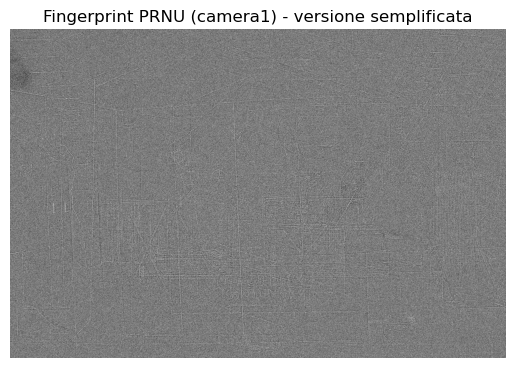

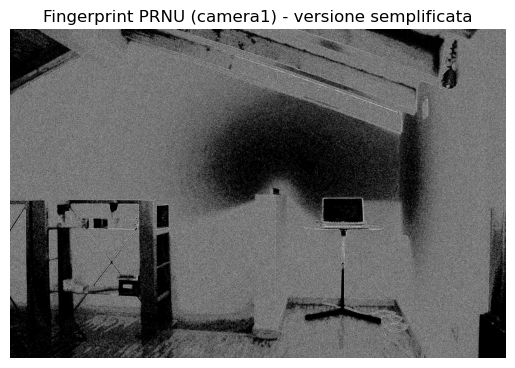

In [13]:
def to_gray(img):
    return cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

def denoise_simple(gray):
    # filtro blur come pseudo-denoiser (faccio un denoising dell'immagine applicando un filtro Gaussiano)
    return cv2.GaussianBlur(gray, (5,5), 0)

def noise_residual(gray):
    #calcolo il noise come differenza tra l'immagine originale e l'immagine denoised
    return gray - denoise_simple(gray)
   
   
        
def estimate_prnu(image_paths):
    acc = None
    count = 0
    #per ogni immagine
    for p in image_paths:
        #carico immagine
        img = load_image_cv(p)
        #trasformo in scala di grigio
        g   = to_gray(img)
        #calcolo il noise residuale
        w   = noise_residual(g)
        #accumulo il noise
        if acc is None:
            acc = w
        else:
            acc += w
        count += 1
    K = acc / max(count, 1)
    # normalizza
    K = (K - K.mean()) / (K.std() + 1e-8)
    return K

#PRNU estratto usando tutte le immagine della camera
PRNU_camera1 = estimate_prnu(camera1_paths)
plt.imshow(PRNU_camera1, cmap='gray')
plt.title("Fingerprint PRNU (camera1) - versione semplificata")
plt.axis('off')
plt.show()

PRNU_camerasame_image_1 = estimate_prnu(camera1_same_image_paths)
plt.imshow(PRNU_camerasame_image_1, cmap='gray')
plt.title("Fingerprint PRNU (camera1) - versione semplificata")
plt.axis('off')
plt.show()

### Funzione di correlazione normalizzata (NCC) su tutta l’immagine (semplificata):



In [ ]:
def ncc(a, b):
    a = a - a.mean()
    b = b - b.mean()
    num = np.sum(a * b)
    den = np.sqrt(np.sum(a*a) * np.sum(b*b)) + 1e-8
    return num / den

def match_prnu(K, path):
    img = load_image_cv(path)
    g   = to_gray(img)
    w   = noise_residual(g)
    # resize se necessario
    if w.shape != K.shape:
        h = min(w.shape[0], K.shape[0])
        w_min = min(w.shape[1], K.shape[1])
        w_crop = w[:h, :w_min]
        K_crop = K[:h, :w_min]
    else:
        w_crop = w
        K_crop = K
    score = ncc(K_crop, w_crop)
    return score

# Demo: confronta immagini note della stessa camera vs una di altra sorgente
for p in test_paths:
    score = match_prnu(PRNU_camera1, p)
    print(os.path.basename(p), "→ PRNU NCC =", round(score, 4))
print("\n\n-----------------")
for p in test_paths:
    score = match_prnu(K_camera1, p)
    print(os.path.basename(p), "→ PRNU NCC =", round(score, 4))

### File Container Analysis – JPEG (QT, marker base) + EXIF coerenza

In [16]:
def check_exif_consistency(path):
    exif = read_exif(path)
    make  = exif.get("Make", "UNKNOWN")
    model = exif.get("Model", "UNKNOWN")
    soft  = exif.get("Software", "UNKNOWN")
    print("File:", os.path.basename(path))
    print("  Make:", make)
    print("  Model:", model)
    print("  Software:", soft)
    if "Photoshop" in str(soft) or "GIMP" in str(soft):
        print("  ⚠ Indizio: immagine probabilmente passata da editor.")
    print()

for p in test_paths:
    check_exif_consistency(p)


#Parsing minimale header JPEG per markers python
# Lettura markers JPEG principali: SOI, APPn, DQT, SOF0, SOS, EOI
def parse_jpeg_markers(path, max_bytes=4096):
    with open(path, "rb") as f:
        data = f.read(max_bytes)
    markers = []
    i = 0
    while i < len(data)-1:
        if data[i] == 0xFF and data[i+1] != 0x00:
            m = data[i+1]
            markers.append(m)
            # salta segmento con lunghezza (eccetto SOI=0xD8, EOI=0xD9)
            if m in [0xD8, 0xD9]:  # SOI/EOI
                i += 2
            else:
                if i+4 <= len(data):
                    seg_len = struct.unpack(">H", data[i+2:i+4])[0]
                    i += 2 + seg_len
                else:
                    break
        else:
            i += 1
    return markers

def markers_to_str(markers):
    name_map = {
        0xD8: "SOI", 0xD9: "EOI",
        0xE0: "APP0", 0xE1: "APP1", 0xE2: "APP2",
        0xDB: "DQT",  0xC0: "SOF0",
        0xC2: "SOF2", 0xC4: "DHT",
        0xDA: "SOS",  0xFE: "COM"
    }
    return [name_map.get(m, f"FF{m:02X}") for m in markers]

for p in test_paths:
    m = parse_jpeg_markers(p)
    print(os.path.basename(p), "markers:")
    print("  ", markers_to_str(m))
    print()


def show_jpeg_info(path):
    print("File:", os.path.basename(path))
    m = parse_jpeg_markers(path)
    print("Markers:", markers_to_str(m))
    exif = read_exif(path)
    print("Make:", exif.get("Make", "N/A"),
          "Model:", exif.get("Model", "N/A"),
          "Software:", exif.get("Software", "N/A"))
    print()

for p in test_paths:
    show_jpeg_info(p)

File: DOM00162.JPG
  Make: SONY
  Model: ILCE-7M3
  Software: Imaging Edge Desktop 3.8.00.11111

File: DOM00168.JPG
  Make: SONY
  Model: ILCE-7M3
  Software: Imaging Edge Desktop 3.8.00.11111

File: DOM00398.JPG
  Make: SONY
  Model: ILCE-7M3
  Software: Imaging Edge Desktop 3.8.00.11111

File: DOM00459.JPG
  Make: SONY
  Model: ILCE-7M3
  Software: Imaging Edge Desktop 3.8.00.11111

File: DOM00460.JPG
  Make: SONY
  Model: ILCE-7M3
  Software: Imaging Edge Desktop 3.8.00.11111

File: DOM00461.JPG
  Make: SONY
  Model: ILCE-7M3
  Software: Imaging Edge Desktop 3.8.00.11111

File: clay-banks-4iTQFfuiFzc-unsplash.jpg
  Make: UNKNOWN
  Model: UNKNOWN
  Software: UNKNOWN

File: iuliu-illes--FMBSd5ZPdk-unsplash.jpg
  Make: UNKNOWN
  Model: UNKNOWN
  Software: UNKNOWN

File: land-o-lakes-inc-S0b7EKTOeV8-unsplash.jpg
  Make: UNKNOWN
  Model: UNKNOWN
  Software: UNKNOWN

File: mike-hindle-UxW63Tbtyjk-unsplash.jpg
  Make: UNKNOWN
  Model: UNKNOWN
  Software: UNKNOWN

File: ny.jpg
  Make: UNKNO

### Physical Integrity

In [19]:
def check_sun_position(path):
    """
    DIDATTICO: Verifica consistenza posizione sole
    Confronta orario EXIF con ombre nell'immagine
    """
    exif = read_exif(path)
    dt_str = exif.get("DateTimeOriginal", None)
    if not dt_str:
        print("❌ No DateTimeOriginal per sun check")
        return
    
    try:
        dt = datetime.strptime(dt_str, "%Y:%m:%d %H:%M:%S")
        hour = dt.hour
        print("Orario EXIF:", dt.strftime("%H:%M"))
        
        # Carica immagine
        img = load_image_cv(path)

        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        
        # Edge detection semplice per ombre
        edges = cv2.Canny(gray, 50, 150)
        
        # Trova oggetti lunghi verticali (alberi, pali)
        contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        long_vertical = []
        
        for cnt in contours:
            # Bounding box
            x, y, w, h = cv2.boundingRect(cnt)
            if h > 100 and w < h * 0.3:  # Alto e stretto
                long_vertical.append((x, y, w, h))
        
        if len(long_vertical) < 2:
            print("❌ Troppi pochi oggetti verticali per analisi ombre")
            return
        
        print(f"📏 Trovati {len(long_vertical)} oggetti verticali")
        
        # Analisi ombre (semplificata)
        shadows_right = 0  # ombre a destra (sole a sinistra)
        shadows_left = 0   # ombre a sinistra (sole a destra)
        
        for i, (x1, y1, w1, h1) in enumerate(long_vertical):
            for j, (x2, y2, w2, h2) in enumerate(long_vertical):
                if i == j: continue
                
                # Distanza orizzontale tra oggetti
                dx = x2 + w2/2 - (x1 + w1/2)
                
                # Se oggetti allineati verticalmente (stessa colonna)
                if abs(dx) < 50:  
                    # Ombra: parte bassa del primo oggetto va verso il secondo?
                    shadow_tip_y = y1 + h1 - 20  # 20px dalla base
                    shadow_base_x = x1 + w1/2
                    
                    if shadow_tip_y > y2 + h2/2:  # ombra va verso l'altro oggetto
                        if dx > 0:
                            shadows_right += 1
                        else:
                            shadows_left += 1
        
        # Verifica consistenza con orario
        sun_east_west = "Est" if hour < 12 else "Ovest"
        shadow_dir = "Sinistra" if shadows_left > shadows_right else "Destra"
        
        print(f"🌅 Sole previsto: {sun_east_west} (ombre {shadow_dir})")
        
        consistent = (hour < 12 and shadow_dir == "Destra") or (hour >= 12 and shadow_dir == "Sinistra")
        
        if consistent:
            print("✅ Ombre consistenti con orario")
        else:
            print("⚠️ INCOERENZA: ombre non corrispondono all'orario!")
            
    except Exception as e:
        print("❌ Errore sun position:", e)

# Demo
print("\n=== SUN POSITION ANALYSIS ===")
for p in test_paths:
    print(p)
    check_sun_position(p)
    print("\n=== ----------- ===")


=== SUN POSITION ANALYSIS ===
data/test\DOM00162.JPG
Orario EXIF: 19:13
📏 Trovati 5 oggetti verticali
🌅 Sole previsto: Ovest (ombre Destra)
⚠️ INCOERENZA: ombre non corrispondono all'orario!

=== ----------- ===
data/test\DOM00168.JPG
Orario EXIF: 19:14
📏 Trovati 18 oggetti verticali
🌅 Sole previsto: Ovest (ombre Destra)
⚠️ INCOERENZA: ombre non corrispondono all'orario!

=== ----------- ===
data/test\DOM00398.JPG
Orario EXIF: 20:04
📏 Trovati 3 oggetti verticali
🌅 Sole previsto: Ovest (ombre Destra)
⚠️ INCOERENZA: ombre non corrispondono all'orario!

=== ----------- ===
data/test\DOM00459.JPG
Orario EXIF: 20:21
📏 Trovati 2 oggetti verticali
🌅 Sole previsto: Ovest (ombre Destra)
⚠️ INCOERENZA: ombre non corrispondono all'orario!

=== ----------- ===
data/test\DOM00460.JPG
Orario EXIF: 20:21
📏 Trovati 3 oggetti verticali
🌅 Sole previsto: Ovest (ombre Destra)
⚠️ INCOERENZA: ombre non corrispondono all'orario!

=== ----------- ===
data/test\DOM00461.JPG
Orario EXIF: 20:21
📏 Trovati 7 ogge

### Aggiungo orario specifico dell'immagine in analisi

<>:15: SyntaxWarning: invalid escape sequence '\c'
<>:18: SyntaxWarning: invalid escape sequence '\s'
<>:15: SyntaxWarning: invalid escape sequence '\c'
<>:18: SyntaxWarning: invalid escape sequence '\s'
C:\Users\guarn\AppData\Local\Temp\ipykernel_23204\2644831953.py:15: SyntaxWarning: invalid escape sequence '\c'
  if (path=="data/test\clay-banks-4iTQFfuiFzc-unsplash.jpg"):
C:\Users\guarn\AppData\Local\Temp\ipykernel_23204\2644831953.py:18: SyntaxWarning: invalid escape sequence '\s'
  if (path=="data/test\same_camera_1.jpg"):



=== SUN POSITION ANALYSIS ===
Orario EXIF: 11:25
data/test\DOM00162.JPG
📏 Trovati 5 oggetti verticali
🌅 Sole previsto: Est (ombre Destra)
✅ Ombre consistenti con orario

=== ----------- ===
Orario EXIF: 11:25
data/test\DOM00168.JPG
📏 Trovati 18 oggetti verticali
🌅 Sole previsto: Est (ombre Destra)
✅ Ombre consistenti con orario

=== ----------- ===
Orario EXIF: 11:25
data/test\DOM00398.JPG
📏 Trovati 3 oggetti verticali
🌅 Sole previsto: Est (ombre Destra)
✅ Ombre consistenti con orario

=== ----------- ===
Orario EXIF: 11:25
data/test\DOM00459.JPG
📏 Trovati 2 oggetti verticali
🌅 Sole previsto: Est (ombre Destra)
✅ Ombre consistenti con orario

=== ----------- ===
Orario EXIF: 11:25
data/test\DOM00460.JPG
📏 Trovati 3 oggetti verticali
🌅 Sole previsto: Est (ombre Destra)
✅ Ombre consistenti con orario

=== ----------- ===
Orario EXIF: 11:25
data/test\DOM00461.JPG
📏 Trovati 7 oggetti verticali
🌅 Sole previsto: Est (ombre Destra)
✅ Ombre consistenti con orario

=== ----------- ===
Orario E

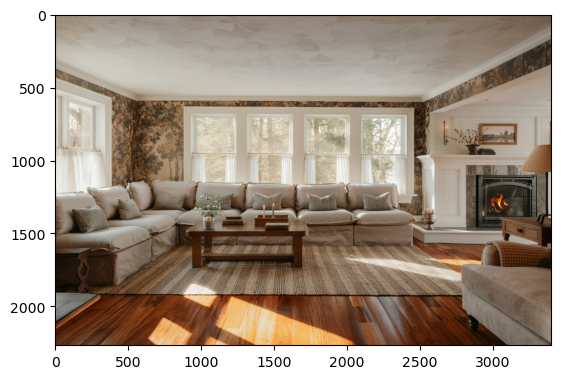

📏 Trovati 83 oggetti verticali
🌅 Sole previsto: Est (ombre Destra)
✅ Ombre consistenti con orario

=== ----------- ===
Orario EXIF: 11:25
data/test\iuliu-illes--FMBSd5ZPdk-unsplash.jpg
❌ Troppi pochi oggetti verticali per analisi ombre

=== ----------- ===
Orario EXIF: 11:25
data/test\land-o-lakes-inc-S0b7EKTOeV8-unsplash.jpg
📏 Trovati 151 oggetti verticali
🌅 Sole previsto: Est (ombre Destra)
✅ Ombre consistenti con orario

=== ----------- ===
Orario EXIF: 11:25
data/test\mike-hindle-UxW63Tbtyjk-unsplash.jpg
📏 Trovati 157 oggetti verticali
🌅 Sole previsto: Est (ombre Sinistra)
⚠️ INCOERENZA: ombre non corrispondono all'orario!

=== ----------- ===
Orario EXIF: 11:25
data/test\ny.jpg
📏 Trovati 124 oggetti verticali
🌅 Sole previsto: Est (ombre Sinistra)
⚠️ INCOERENZA: ombre non corrispondono all'orario!

=== ----------- ===
Orario EXIF: 11:25
data/test\portrait_mode.jpg
📏 Trovati 2 oggetti verticali
🌅 Sole previsto: Est (ombre Destra)
✅ Ombre consistenti con orario

=== ----------- ===
O

In [31]:
def check_sun_position_custom(path,date_time):
    """
    DIDATTICO: Verifica consistenza posizione sole
    Confronta orario EXIF con ombre nell'immagine
    """
    
    try:
        dt = datetime.strptime(date_time, "%H:%M")
        hour = dt.hour
        print("Orario EXIF:", dt.strftime("%H:%M"))
        
        # Carica immagine
        img = load_image_cv(path)
        print(path)
        if (path=="data/test\clay-banks-4iTQFfuiFzc-unsplash.jpg"):
            plt.imshow(img)
            plt.show()
        if (path=="data/test\same_camera_1.jpg"):
            plt.imshow(img)
            plt.show()
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        
        # Edge detection semplice per ombre
        edges = cv2.Canny(gray, 50, 150)
        
        # Trova oggetti lunghi verticali (alberi, pali)
        contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        long_vertical = []
        
        for cnt in contours:
            # Bounding box
            x, y, w, h = cv2.boundingRect(cnt)
            if h > 100 and w < h * 0.3:  # Alto e stretto
                long_vertical.append((x, y, w, h))
        
        if len(long_vertical) < 2:
            print("❌ Troppi pochi oggetti verticali per analisi ombre")
            return
        
        print(f"📏 Trovati {len(long_vertical)} oggetti verticali")
        
        # Analisi ombre (semplificata)
        shadows_right = 0  # ombre a destra (sole a sinistra)
        shadows_left = 0   # ombre a sinistra (sole a destra)
        
        for i, (x1, y1, w1, h1) in enumerate(long_vertical):
            for j, (x2, y2, w2, h2) in enumerate(long_vertical):
                if i == j: continue
                
                # Distanza orizzontale tra oggetti
                dx = x2 + w2/2 - (x1 + w1/2)
                
                # Se oggetti allineati verticalmente (stessa colonna)
                if abs(dx) < 50:  
                    # Ombra: parte bassa del primo oggetto va verso il secondo?
                    shadow_tip_y = y1 + h1 - 20  # 20px dalla base
                    shadow_base_x = x1 + w1/2
                    
                    if shadow_tip_y > y2 + h2/2:  # ombra va verso l'altro oggetto
                        if dx > 0:
                            shadows_right += 1
                        else:
                            shadows_left += 1
        
        # Verifica consistenza con orario
        sun_east_west = "Est" if hour < 12 else "Ovest"
        shadow_dir = "Sinistra" if shadows_left > shadows_right else "Destra"
        
        print(f"🌅 Sole previsto: {sun_east_west} (ombre {shadow_dir})")
        
        consistent = (hour < 12 and shadow_dir == "Destra") or (hour >= 12 and shadow_dir == "Sinistra")
        
        if consistent:
            print("✅ Ombre consistenti con orario")
        else:
            print("⚠️ INCOERENZA: ombre non corrispondono all'orario!")
            
    except Exception as e:
        print("❌ Errore sun position:", e)

# Demo
print("\n=== SUN POSITION ANALYSIS ===")
for p in test_paths:
    check_sun_position_custom(p,'11:25')
    print("\n=== ----------- ===")

### La posizione del solo dipende dalla posizione, aggiungo latidudine e longitudine

In [33]:
def check_sun_position_italia(path, lat=37.5, lon=15.0):  # Catania default
    """
    Sun position corretto per ITALIA
    lat/lon = Catania (modifica per la tua città)
    """
    exif = read_exif(path)
    dt_str = exif.get("DateTimeOriginal")
    if not dt_str:
        print("❌ No DateTimeOriginal")
        return
    
    dt = datetime.strptime(dt_str, "%Y:%m:%d %H:%M:%S")
    hour = dt.hour
    
    # Calcola azimut sole approssimativo per Italia
    # Formula semplificata (precisa entro ~10°)
    solar_noon = 12.0  # ora solare (senza ora legale)
    sun_azimuth = 180  # mezzogiorno = Sud
    
    if hour < solar_noon:
        # Mattina: sole Sud-Est → ombre Nord-Ovest
        sun_azimuth = 135 + (solar_noon - hour) * 10
        expected_shadow_dir = "Nord-Ovest (Sinistra-Superiore)"
    else:
        # Pomeriggio: sole Sud-Ovest → ombre Nord-Est
        sun_azimuth = 225 - (hour - solar_noon) * 10  
        expected_shadow_dir = "Nord-Est (Destra-Superiore)"
    
    print(f"📍 Posizione: {lat}°N, {lon}°E")
    print(f"🕐 Orario: {dt.strftime('%H:%M')}")
    print(f"🌅 Sole azimut: ~{int(sun_azimuth)}°")
    print(f"← Ombre attese: {expected_shadow_dir}")
    
    # Analisi ombre reale dall'immagine (come prima)
    img = load_image_cv(path)
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    edges = cv2.Canny(gray, 50, 150)
    
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    long_objects = [(cv2.boundingRect(cnt)) for cnt in contours 
                   if cv2.boundingRect(cnt)[3] > 100 and cv2.boundingRect(cnt)[2] < cv2.boundingRect(cnt)[3]*0.3]
    
    if len(long_objects) < 2:
        print("❌ Pochi oggetti verticali")
        return
    
    shadow_left, shadow_right = 0, 0
    for i, (x1,y1,w1,h1) in enumerate(long_objects):
        for j, (x2,y2,w2,h2) in enumerate(long_objects):
            if i == j: continue
            dx = x2 + w2/2 - (x1 + w1/2)
            if abs(dx) < 50 and y1 + h1 > y2 + h2/2:
                if dx > 0: shadow_right += 1
                else: shadow_left += 1
    
    observed_dir = "Sinistra-Superiore" if shadow_left > shadow_right else "Destra-Superiore"
    
    print(f"👁️  Ombre osservate: {observed_dir}")
    
    # Verifica
    morning_expected = "Destra-Superiore" if hour < 12 else "Sinistra-Superiore"
    consistent = observed_dir == morning_expected
    
    status = "✅ CONSISTENTE" if consistent else "⚠️ INCOERENZA!"
    print(f"{status}")
    
    return consistent

# Test Catania
for p in test_paths:
    print(p)
    check_sun_position_italia(p, lat=37.5, lon=15.0)
    print("\n=== ----------- ===")


data/test\DOM00162.JPG
📍 Posizione: 37.5°N, 15.0°E
🕐 Orario: 19:13
🌅 Sole azimut: ~155°
← Ombre attese: Nord-Est (Destra-Superiore)
👁️  Ombre osservate: Destra-Superiore
⚠️ INCOERENZA!

=== ----------- ===
data/test\DOM00168.JPG
📍 Posizione: 37.5°N, 15.0°E
🕐 Orario: 19:14
🌅 Sole azimut: ~155°
← Ombre attese: Nord-Est (Destra-Superiore)
👁️  Ombre osservate: Destra-Superiore
⚠️ INCOERENZA!

=== ----------- ===
data/test\DOM00398.JPG
📍 Posizione: 37.5°N, 15.0°E
🕐 Orario: 20:04
🌅 Sole azimut: ~145°
← Ombre attese: Nord-Est (Destra-Superiore)
👁️  Ombre osservate: Destra-Superiore
⚠️ INCOERENZA!

=== ----------- ===
data/test\DOM00459.JPG
📍 Posizione: 37.5°N, 15.0°E
🕐 Orario: 20:21
🌅 Sole azimut: ~145°
← Ombre attese: Nord-Est (Destra-Superiore)
👁️  Ombre osservate: Destra-Superiore
⚠️ INCOERENZA!

=== ----------- ===
data/test\DOM00460.JPG
📍 Posizione: 37.5°N, 15.0°E
🕐 Orario: 20:21
🌅 Sole azimut: ~145°
← Ombre attese: Nord-Est (Destra-Superiore)
👁️  Ombre osservate: Destra-Superiore
⚠️ INC

### Abbiamo bisogno anche della posizione della fotocamera

In [35]:
def check_sun_position_smart(path, lat=37.5, lon=15.0):
    """
    Sun position RELATIVA all'orientamento foto (EXIF)
    """
    exif = read_exif(path)
    
    # 1. ORA e POSIZIONE GEOGRAFICA
    dt_str = exif.get("DateTimeOriginal")
    if not dt_str:
        print("❌ No DateTimeOriginal")
        return False
        
    dt = datetime.strptime(dt_str, "%Y:%m:%d %H:%M:%S")
    hour = dt.hour
    
    # 2. ORIENTAMENTO FOTOCAMERA (EXIF Orientation + Compass)
    orientation = exif.get("Orientation", 1)  # 1=Normale
    compass = exif.get(34853, None)  # GPS ImgDirection (gradi)
    
    if compass:
        camera_azimuth = float(compass)
        print(f"🧭 Fotocamera puntata: {camera_azimuth:.0f}°")
    else:
        print("⚠️ No GPS compass → assumo SUD (180°)")
        camera_azimuth = 180.0
    
    # 3. AZIMUT SOLE approssimativo (Italia)
    solar_noon = 12.0
    if hour < solar_noon:
        sun_azimuth = 90 + (solar_noon - hour) * 15  # Sole Sud-Est
    else:
        sun_azimuth = 270 - (hour - solar_noon) * 15  # Sole Sud-Ovest
    
    print(f"🕐 Orario: {dt.strftime('%H:%M')}")
    print(f"🌅 Sole azimut: {sun_azimuth:.0f}°")
    
    # 4. DIREZIONE OMBRA RELATIVA alla fotocamera
    shadow_relative = (sun_azimuth - camera_azimuth + 360) % 360
    
    if 270 <= shadow_relative < 90:  # Ombra a SINISTRA
        observed_dir = "SINISTRA"
    elif 90 <= shadow_relative < 270:  # Ombra a DESTRA  
        observed_dir = "DESTRA"
    else:
        observed_dir = "FRONTALE/DORSALE"
    
    print(f"📸 Fotocamera: {camera_azimuth:.0f}°")
    print(f"← Ombra attesa: {observed_dir}")
    
    # 5. ANALISI OMBRE REALE dall'immagine
    img = load_image_cv(path)
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    edges = cv2.Canny(gray, 50, 150)
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    long_objects = [cv2.boundingRect(cnt) for cnt in contours 
                   if cv2.boundingRect(cnt)[3] > 100 and cv2.boundingRect(cnt)[2] < cv2.boundingRect(cnt)[3]*0.3]
    
    if len(long_objects) < 2:
        print("❌ Pochi oggetti verticali")
        return False
    
    shadow_left_count, shadow_right_count = 0, 0
    for i, (x1,y1,w1,h1) in enumerate(long_objects):
        for j, (x2,y2,w2,h2) in enumerate(long_objects):
            if i == j: continue
            dx = x2 + w2/2 - (x1 + w1/2)
            if abs(dx) < 50 and y1 + h1 > y2 + h2/2:  # ombra dalla base
                if dx > 0: shadow_right_count += 1
                else: shadow_left_count += 1
    
    observed_image_dir = "SINISTRA" if shadow_left_count > shadow_right_count else "DESTRA"
    print(f"👁️  Ombre nell'immagine: {observed_image_dir}")
    
    # 6. VERIFICA CONSISTENZA
    consistent = observed_image_dir == observed_dir
    
    status = "✅ FISICA COERENTE" if consistent else "⚠️ INCOERENZA FISICA!"
    print(f"{status}")
    
    return consistent

# Test
for p in test_paths:
    print(p)
    check_sun_position_smart(p, lat=37.5, lon=15.0)
    print("\n=== ----------- ===")


data/test\DOM00162.JPG
⚠️ No GPS compass → assumo SUD (180°)
🕐 Orario: 19:13
🌅 Sole azimut: 165°
📸 Fotocamera: 180°
← Ombra attesa: FRONTALE/DORSALE
👁️  Ombre nell'immagine: DESTRA
⚠️ INCOERENZA FISICA!

=== ----------- ===
data/test\DOM00168.JPG
⚠️ No GPS compass → assumo SUD (180°)
🕐 Orario: 19:14
🌅 Sole azimut: 165°
📸 Fotocamera: 180°
← Ombra attesa: FRONTALE/DORSALE
👁️  Ombre nell'immagine: DESTRA
⚠️ INCOERENZA FISICA!

=== ----------- ===
data/test\DOM00398.JPG
⚠️ No GPS compass → assumo SUD (180°)
🕐 Orario: 20:04
🌅 Sole azimut: 150°
📸 Fotocamera: 180°
← Ombra attesa: FRONTALE/DORSALE
👁️  Ombre nell'immagine: DESTRA
⚠️ INCOERENZA FISICA!

=== ----------- ===
data/test\DOM00459.JPG
⚠️ No GPS compass → assumo SUD (180°)
🕐 Orario: 20:21
🌅 Sole azimut: 150°
📸 Fotocamera: 180°
← Ombra attesa: FRONTALE/DORSALE
👁️  Ombre nell'immagine: DESTRA
⚠️ INCOERENZA FISICA!

=== ----------- ===
data/test\DOM00460.JPG
⚠️ No GPS compass → assumo SUD (180°)
🕐 Orario: 20:21
🌅 Sole azimut: 150°
📸 Fotoc

## OPTICAL BLUR vs PORTRAIT MODE

<>:136: SyntaxWarning: invalid escape sequence '\D'
<>:137: SyntaxWarning: invalid escape sequence '\p'
<>:136: SyntaxWarning: invalid escape sequence '\D'
<>:137: SyntaxWarning: invalid escape sequence '\p'
C:\Users\guarn\AppData\Local\Temp\ipykernel_23204\1584212133.py:136: SyntaxWarning: invalid escape sequence '\D'
  'data/test\DOM00168.jpg',
C:\Users\guarn\AppData\Local\Temp\ipykernel_23204\1584212133.py:137: SyntaxWarning: invalid escape sequence '\p'
  'data/test\portrait_mode.jpg',









🔍 ANALISI: data/test\DOM00168.jpg
📊 Laplacian variance (nitidezza): 63.63
📊 Noise variance: 55.5823


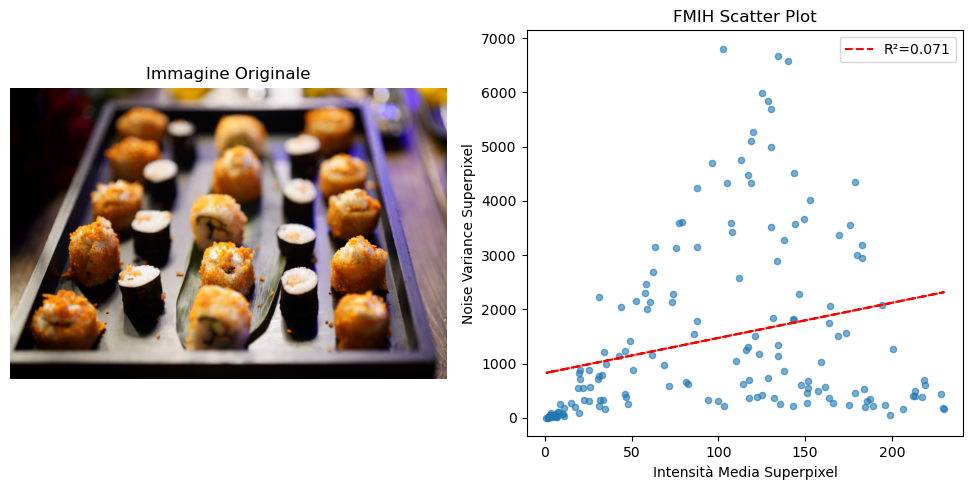


🎯 VERDETTO FORENSE
✅ PROBABILMENTE AUTENTICO: Noise naturale
   (Consistente con optical blur)
📏 Immagine complessivamente SFOCATA
📈 FMIH: Relazione non-lineare → SOSPETTO







🔍 ANALISI: data/test\portrait_mode.jpg
📊 Laplacian variance (nitidezza): 160.29
📊 Noise variance: 40.7467


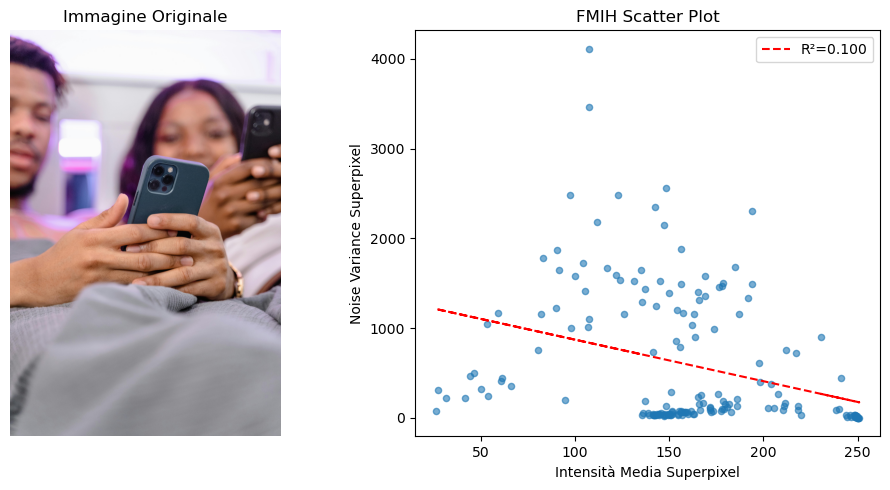


🎯 VERDETTO FORENSE
⚠️  SOSPETTO: Noise troppo basso → possibile PORTRAIT MODE!
   (Blur digitale de-noisa l'immagine)
📏 Immagine NITIDA
📈 FMIH: Relazione non-lineare → SOSPETTO

✅ SCRIPT COMPLETATO!


In [43]:
# =======================================================
# DETECTOR PORTRAIT MODE vs OPTICAL BLUR
# Features: Noise Variance + IGH ((Intensity-Gradient Histogram) Approximation
# =======================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.segmentation import slic
from skimage.measure import regionprops
from scipy.ndimage import gaussian_filter
import seaborn as sns

def variance_of_laplacian(image):
    # Misura nitidezza dandoci dettagli su quanto l'immagine è "ricca di contenuti ad altra frequenza", infatti
    # nel caso di Portrait Mode questo valore è + basso riseptto alla sfocatura naturale
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    laplacian_var = cv2.Laplacian(gray, cv2.CV_64F).var()
    return laplacian_var

def compute_noise_variance(image, window_size=15):
    #calcolo la varianza del rumore come la media delle varianze per un numero finito dipatch
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    h, w = gray.shape
    variances = []
    
    for i in range(0, h-window_size, window_size//2):
        for j in range(0, w-window_size, window_size//2):
            patch = gray[i:i+window_size, j:j+window_size]
            var = np.var(patch)
            variances.append(var)
    
    return np.mean(variances)

def extract_superpixels(image, n_segments=200):
    #analizzo l'immagine a blocchi
    img_rgb = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    segments = slic(img_rgb, n_segments=n_segments, compactness=10, sigma=1)
    return segments

def compute_fmih(image, n_segments=200):
    """Focus Manipulation Inconsistency Histogram (FMIH)"""
    segments = extract_superpixels(image, n_segments)
    
    # Calcola features per superpixel
    intensities = []
    noises = []
    
    for region in regionprops(segments):
        coords = region.coords
        if len(coords) < 10: continue  # superpixel troppo piccolo
            
        patch = image[coords[:,0], coords[:,1]]
        mean_intensity = np.mean(patch)
        noise_var = np.var(patch)
        
        intensities.append(mean_intensity)
        noises.append(noise_var)
    
    return np.array(intensities), np.array(noises)



def analyze_portrait_mode(image_path):
    """DETECTOR PRINCIPALE"""
    print(f"🔍 ANALISI: {image_path}")
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # 1. METRICHE BASE
    laplacian_var = variance_of_laplacian(image)
    noise_var = compute_noise_variance(image)
    
    print(f"📊 Laplacian variance (nitidezza): {laplacian_var:.2f}")
    print(f"📊 Noise variance: {noise_var:.4f}")
    
    # 2. FMIH ANALYSIS
    intensities, noises = compute_fmih(image)
    
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.imshow(image)
    plt.title("Immagine Originale")
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.scatter(intensities, noises, alpha=0.6, s=20)
    plt.xlabel("Intensità Media Superpixel")
    plt.ylabel("Noise Variance Superpixel")
    plt.title("FMIH Scatter Plot")
    
    # Regressione lineare (dovrebbe essere lineare per authentic)
    from scipy.stats import linregress
    slope, intercept, r_value, _, _ = linregress(intensities, noises)
    plt.plot(intensities, slope*intensities + intercept, 'r--', label=f'R²={r_value**2:.3f}')
    plt.legend()
    
    
    plt.tight_layout()
    plt.show()
    
    # 3. VERDETTO FORENSE
    print("\n" + "="*60)
    print("🎯 VERDETTO FORENSE")
    print("="*60)
    
    if noise_var < 50:  # Soglia empirica (calibrare sul dataset)
        print("⚠️  SOSPETTO: Noise troppo basso → possibile PORTRAIT MODE!")
        print("   (Blur digitale de-noisa l'immagine)")
    else:
        print("✅ PROBABILMENTE AUTENTICO: Noise naturale")
        print("   (Consistente con optical blur)")
    
    if laplacian_var < 100:
        print("📏 Immagine complessivamente SFOCATA")
    else:
        print("📏 Immagine NITIDA")
    
    # R² FMIH (dovrebbe essere alto per authentic)
    if r_value**2 > 0.7:
        print("📈 FMIH: Relazione lineare naturale → AUTENTICO")
    else:
        print("📈 FMIH: Relazione non-lineare → SOSPETTO")
    
    return {
        'laplacian_var': laplacian_var,
        'noise_var': noise_var,
        'fmih_r2': r_value**2
    }

# ===================================
# TEST
# ===================================
test_paths = [
    'data/test\DOM00168.jpg',    
     'data/test\portrait_mode.jpg',
]

for path in test_paths:
    print("\n\n\n\n\n\n")
    if os.path.exists(path):
        results = analyze_portrait_mode(path)
    else:
        print(f"❌ File non trovato: {path}")

print("\n✅ SCRIPT COMPLETATO!")


### Provenance Analysis

Similarità Corpus: {'A': 0.28118393234672306, 'B': 0.35176991150442477, 'C': 0.3373493975903614, 'D': 0.2987551867219917}
Cluster Origine: {frozenset({'Q', 'C', 'B'}): ['Q', 'C', 'B'], frozenset({'A'}): ['A'], frozenset({'D'}): ['D']}


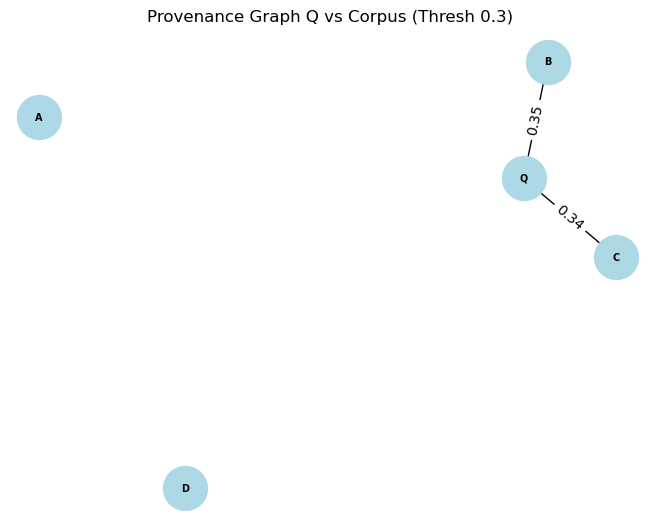

Storia Probabile: Q derivata da [1 2 3] (Crop/Splice scores: [0.35176991 0.3373494  0.29875519])


In [52]:
import cv2
import numpy as np
from skimage.feature import ORB, match_descriptors
from sklearn.metrics.pairwise import cosine_similarity
import networkx as nx
import matplotlib.pyplot as plt
import plotly.graph_objects as go

# 1. Carica immagini (sostituisci paths)
corpus_paths = ['A.jpg', 'B.jpg', 'C.jpg', 'D.jpg']  # Corpus
query_path = 'Q1.jpg'  # Query attuale

def extract_features(img):
    orb = cv2.ORB_create(nfeatures=500)
    kp, des = orb.detectAndCompute(img, None)
    return des.astype(np.float32) if des is not None else np.empty((0, 32))

def similarity_cbir(query_img, corpus_imgs):
    q_des = extract_features(query_img)
    sim_scores = []
    for i, c_img in enumerate(corpus_imgs):
        c_des = extract_features(c_img)
        if len(q_des) > 0 and len(c_des) > 0:
            matches = match_descriptors(q_des, c_des, metric='euclidean', cross_check=True)
            sim = len(matches) / min(len(q_des), len(c_des))  # Match ratio
        else:
            sim = 0
        sim_scores.append(sim)
    return np.array(sim_scores)

# Carica
root='./data/provenance/'
corpus_imgs = [cv2.imread(root+p, 0) for p in corpus_paths]
query_img = cv2.imread(root+query_path, 0)

# 2. CBIR Scores
scores = similarity_cbir(query_img, corpus_imgs)
print("Similarità Corpus:", dict(zip(['A','B','C','D'], scores)))

# 3. GRAPH + CLUSTERING
G = nx.Graph()
G.add_nodes_from(['Q'] + ['A','B','C','D'])
for i, score in enumerate(scores):
    if score > 0.3:  # Threshold crop/splice
        G.add_edge('Q', ['A','B','C','D'][i], weight=round(score,2))

# Clustering (Louvain-like simple)
communities = nx.community.greedy_modularity_communities(G)
print("Cluster Origine:", {c: list(c) for c in communities})

# 4. VISUALIZZA GRAFO
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_color='lightblue', 
        node_size=1000, font_size=7, font_weight='bold')
edge_labels = nx.get_edge_attributes(G,'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels)
plt.title(f'Provenance Graph Q vs Corpus (Thresh 0.3)')
plt.show()

# STORY RECONSTRUCTION
top_matches = np.argsort(scores)[-3:][::-1]
print(f"Storia Probabile: Q derivata da {top_matches} (Crop/Splice scores: {scores[top_matches]})")